
# Triadic Cell Notebook v26
## Shape → complement → declared value

This notebook codes the triad directly.

The chain is:

1. **Shape**
   - the query mold
   - what is already implied but not yet declared

2. **Complement**
   - the missing-shape operator
   - what must be added for lawful closure

3. **Declared value**
   - the late readout
   - what the chain becomes after closure

The law is:

$$
V_{l+1} = \operatorname{mix}(S_l, B_{l+1})
$$

So a layer's shape becomes part of the next layer's value,
mixed with the next layer's own local shape.

This notebook shows that the same query shape can:
- retrieve something that already exists
- expose the missing complement of something partial



## Practical meaning

This is still runtime logic, not base-model training.

The query enters as shape.
For each candidate chain the runtime computes:

- retrieve fit
- missing complement
- forward chain projection
- declared value

So the same query produces:

$$
Q \to (\text{best closure},\ \text{missing complement},\ \text{declared value})
$$


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.



## Canonical triadic chain


In [2]:

n_classes = 4
dim = 6

base_molds = np.array([
    [
        [0.95, 0.15, 0.10, 0.20, 0.30, 0.10],
        [0.70, 0.25, 0.45, 0.30, 0.45, 0.20],
        [0.55, 0.20, 0.60, 0.25, 0.70, 0.35],
    ],
    [
        [0.10, 0.95, 0.15, 0.25, 0.10, 0.30],
        [0.25, 0.72, 0.25, 0.50, 0.25, 0.45],
        [0.20, 0.58, 0.30, 0.70, 0.30, 0.72],
    ],
    [
        [0.20, 0.10, 0.95, 0.15, 0.25, 0.12],
        [0.45, 0.25, 0.75, 0.30, 0.42, 0.22],
        [0.62, 0.22, 0.55, 0.25, 0.72, 0.30],
    ],
    [
        [0.15, 0.22, 0.18, 0.95, 0.12, 0.35],
        [0.28, 0.42, 0.25, 0.75, 0.22, 0.58],
        [0.35, 0.72, 0.30, 0.60, 0.25, 0.78],
    ],
], dtype=float)

def normalize01(x):
    return np.clip(x, 0.0, 1.0)

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def chain_mix(prev_shape: np.ndarray, local_mold: np.ndarray, alpha: float = 0.58):
    return normalize01(alpha * prev_shape + (1.0 - alpha) * local_mold)

def build_chain_for_class(cls: int):
    s0 = normalize01(base_molds[cls, 0].copy())
    s1 = chain_mix(s0, base_molds[cls, 1], alpha=0.58)
    s2 = chain_mix(s1, base_molds[cls, 2], alpha=0.58)
    return [s0, s1, s2]

chains = {cls: build_chain_for_class(cls) for cls in range(n_classes)}
pd.DataFrame(chains[0], index=["shape", "bridge_value", "declared_value"])


,0,1,2,3,4,5
shape,0.9500,0.15000,0.10000,0.20000,0.30000,0.10000
bridge_value,0.8450,0.19200,0.24700,0.24200,0.36300,0.14200
declared_value,0.7211,0.19536,0.39526,0.24536,0.50454,0.22936



## Query corruption


In [3]:

QUERY_MODES = ["existing", "partial", "noisy", "ambiguous", "inverse_hint"]
QUERY_WEIGHTS = np.array([0.28, 0.28, 0.18, 0.16, 0.10], dtype=float)
QUERY_WEIGHTS = QUERY_WEIGHTS / QUERY_WEIGHTS.sum()

def make_query(cls: int, mode: str):
    target = chains[cls][0].copy()
    q = target.copy()

    if mode == "existing":
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "partial":
        mask = rng.random(q.shape[0]) < 0.40
        q[mask] = 0.0
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "noisy":
        q += rng.normal(0.0, 0.08, size=q.shape[0])

    elif mode == "ambiguous":
        alt = int((cls + rng.integers(1, n_classes)) % n_classes)
        q = 0.58 * target + 0.42 * chains[alt][0] + rng.normal(0.0, 0.03, size=q.shape[0])

    elif mode == "inverse_hint":
        inv = 1.0 - target
        q = 0.65 * target + 0.35 * inv + rng.normal(0.0, 0.03, size=q.shape[0])
        mask = rng.random(q.shape[0]) < 0.20
        q[mask] = 0.0

    return normalize01(q)



## Triadic evaluation


In [4]:

def triadic_evaluate(query: np.ndarray, cls: int):
    s0, s1, s2 = chains[cls]

    retrieve_fit = cosine_similarity(query, s0)

    missing = normalize01(np.maximum(s0 - query, 0.0))
    excess = normalize01(np.maximum(query - s0, 0.0))
    residual_energy = float(np.mean(np.abs(s0 - query)))

    folded0 = normalize01(query + missing - 0.25 * excess)

    projected1 = chain_mix(folded0, base_molds[cls, 1], alpha=0.58)
    projected2 = chain_mix(projected1, base_molds[cls, 2], alpha=0.58)

    bridge_energy = (
        0.40 * residual_energy
        + 0.20 * np.mean(missing)
        + 0.20 * np.mean(excess)
        + 0.20 * (1.0 - retrieve_fit)
    )

    return {
        "class": cls,
        "retrieve_fit": float(retrieve_fit),
        "residual_energy": float(residual_energy),
        "bridge_energy": float(bridge_energy),
        "missing": missing,
        "excess": excess,
        "folded0": folded0,
        "projected1": projected1,
        "declared_value": projected2,
    }

def triadic_query(query: np.ndarray):
    results = [triadic_evaluate(query, cls) for cls in range(n_classes)]

    results = sorted(
        results,
        key=lambda r: (r["retrieve_fit"] - 0.55 * r["bridge_energy"]),
        reverse=True,
    )
    best = results[0]
    second = results[1]
    margin = float(
        (best["retrieve_fit"] - 0.55 * best["bridge_energy"])
        - (second["retrieve_fit"] - 0.55 * second["bridge_energy"])
    )

    declared = best["retrieve_fit"] > 0.90 and best["residual_energy"] < 0.08
    resolution_mode = "retrieve" if declared else "grow"

    return best, results, margin, resolution_mode



## Single example


In [5]:

example_cls = 2
example_mode = "partial"
q = make_query(example_cls, example_mode)
best, all_results, margin, resolution_mode = triadic_query(q)

single_example = pd.DataFrame([{
    "true_class": example_cls,
    "query_mode": example_mode,
    "predicted_class": best["class"],
    "resolution_mode": resolution_mode,
    "margin": margin,
    "retrieve_fit": best["retrieve_fit"],
    "residual_energy": best["residual_energy"],
    "bridge_energy": best["bridge_energy"],
    "missing_mass": float(best["missing"].mean()),
}])
single_example


,true_class,query_mode,predicted_class,resolution_mode,margin,retrieve_fit,residual_energy,bridge_energy,missing_mass
0,2,partial,2,retrieve,0.764733,0.973714,0.045708,0.032682,0.042689



## Generate a triadic query world


In [6]:

rows = []
n_per_class = 500

for cls in range(n_classes):
    for _ in range(n_per_class):
        mode = rng.choice(QUERY_MODES, p=QUERY_WEIGHTS)
        q = make_query(cls, mode)
        best, all_results, margin, resolution_mode = triadic_query(q)

        rows.append({
            "true_class": cls,
            "query_mode": mode,
            "predicted_class": best["class"],
            "correct": int(best["class"] == cls),
            "resolution_mode": resolution_mode,
            "margin": margin,
            "retrieve_fit": best["retrieve_fit"],
            "residual_energy": best["residual_energy"],
            "bridge_energy": best["bridge_energy"],
            "missing_mass": float(best["missing"].mean()),
            "excess_mass": float(best["excess"].mean()),
            "declared_value_norm": float(np.linalg.norm(best["declared_value"])),
        })

triad_df = pd.DataFrame(rows)
triad_df.head()


,true_class,query_mode,predicted_class,correct,resolution_mode,margin,retrieve_fit,residual_energy,bridge_energy,missing_mass,excess_mass,declared_value_norm
0,0,noisy,0,1,retrieve,0.712803,0.991786,0.055438,0.034906,0.024242,0.031196,1.056425
1,0,noisy,0,1,retrieve,0.657601,0.993137,0.040311,0.025559,0.024010,0.016301,1.049698
2,0,partial,3,0,grow,0.034412,0.629071,0.280096,0.242243,0.252897,0.027199,1.154002
3,0,noisy,0,1,retrieve,0.754004,0.997933,0.032016,0.019623,0.008873,0.023143,1.054160
4,0,noisy,0,1,retrieve,0.762543,0.993433,0.041873,0.026437,0.016667,0.025207,1.053954



## Core results


In [7]:

core_summary = pd.DataFrame([{
    "overall_accuracy": float(triad_df["correct"].mean()),
    "retrieve_fraction": float((triad_df["resolution_mode"] == "retrieve").mean()),
    "grow_fraction": float((triad_df["resolution_mode"] == "grow").mean()),
    "mean_margin": float(triad_df["margin"].mean()),
    "mean_retrieve_fit": float(triad_df["retrieve_fit"].mean()),
    "mean_bridge_energy": float(triad_df["bridge_energy"].mean()),
}])
core_summary


,overall_accuracy,retrieve_fraction,grow_fraction,mean_margin,mean_retrieve_fit,mean_bridge_energy
0,0.8635,0.545,0.455,0.491992,0.92484,0.075155


In [8]:

by_mode = (
    triad_df.groupby("query_mode")[[
        "correct",
        "margin",
        "retrieve_fit",
        "residual_energy",
        "bridge_energy",
        "missing_mass",
    ]]
    .mean()
    .reset_index()
    .sort_values("correct", ascending=False)
)
by_mode


,query_mode,correct,margin,retrieve_fit,residual_energy,bridge_energy,missing_mass
1,existing,1.000000,0.677723,0.999084,0.016069,0.009824,0.008055
3,noisy,1.000000,0.631763,0.986294,0.060292,0.038917,0.030900
0,ambiguous,0.996951,0.138174,0.885091,0.143083,0.108832,0.071336
2,inverse_hint,0.782857,0.162978,0.819957,0.233381,0.176037,0.095776
4,partial,0.591623,0.527511,0.868806,0.139870,0.110160,0.132333


In [9]:

resolution_mix = (
    triad_df.groupby(["query_mode", "resolution_mode"])
    .size()
    .reset_index(name="count")
)
resolution_mix["fraction_within_mode"] = (
    resolution_mix["count"] /
    resolution_mix.groupby("query_mode")["count"].transform("sum")
)
resolution_mix


,query_mode,resolution_mode,count,fraction_within_mode
0,ambiguous,grow,328,1.000000
1,existing,retrieve,525,1.000000
2,inverse_hint,grow,175,1.000000
3,noisy,grow,55,0.137845
4,noisy,retrieve,344,0.862155
5,partial,grow,352,0.614311
6,partial,retrieve,221,0.385689



## Same query shape: retrieve or grow


In [10]:

retrieve_modes = {"existing"}
grow_modes = {"partial", "noisy", "ambiguous", "inverse_hint"}

retrieve_eval = triad_df[triad_df["query_mode"].isin(retrieve_modes)].copy()
grow_eval = triad_df[triad_df["query_mode"].isin(grow_modes)].copy()

same_query_summary = pd.DataFrame([{
    "retrieve_case_correct": float(retrieve_eval["correct"].mean()),
    "retrieve_case_retrieve_mode_rate": float((retrieve_eval["resolution_mode"] == "retrieve").mean()),
    "grow_case_correct": float(grow_eval["correct"].mean()),
    "grow_case_grow_mode_rate": float((grow_eval["resolution_mode"] == "grow").mean()),
}])
same_query_summary


,retrieve_case_correct,retrieve_case_retrieve_mode_rate,grow_case_correct,grow_case_grow_mode_rate
0,1.0,1.0,0.814915,0.616949



## Sample mode summaries


In [11]:

sample_rows = []
for mode in QUERY_MODES:
    q = make_query(0, mode)
    best, _, margin, resolution_mode = triadic_query(q)
    sample_rows.append({
        "query_mode": mode,
        "predicted_class": best["class"],
        "resolution_mode": resolution_mode,
        "margin": margin,
        "retrieve_fit": best["retrieve_fit"],
        "missing_mass": float(best["missing"].mean()),
        "bridge_energy": best["bridge_energy"],
    })

sample_df = pd.DataFrame(sample_rows)
sample_df


,query_mode,predicted_class,resolution_mode,margin,retrieve_fit,missing_mass,bridge_energy
0,existing,0,retrieve,0.756059,0.999559,0.005429,0.006503
1,partial,3,grow,0.660022,0.905348,0.296493,0.196826
2,noisy,0,retrieve,0.663743,0.981353,0.014751,0.044114
3,ambiguous,0,grow,0.146652,0.888985,0.073254,0.116143
4,inverse_hint,0,grow,0.193001,0.834525,0.075474,0.164748


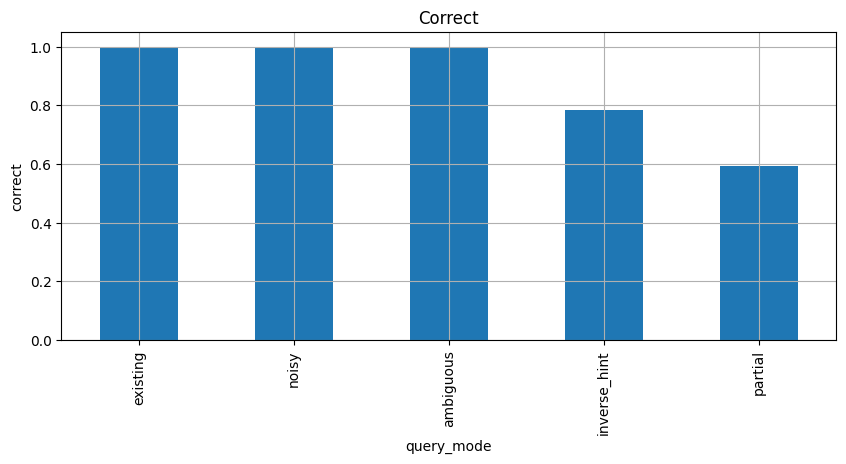

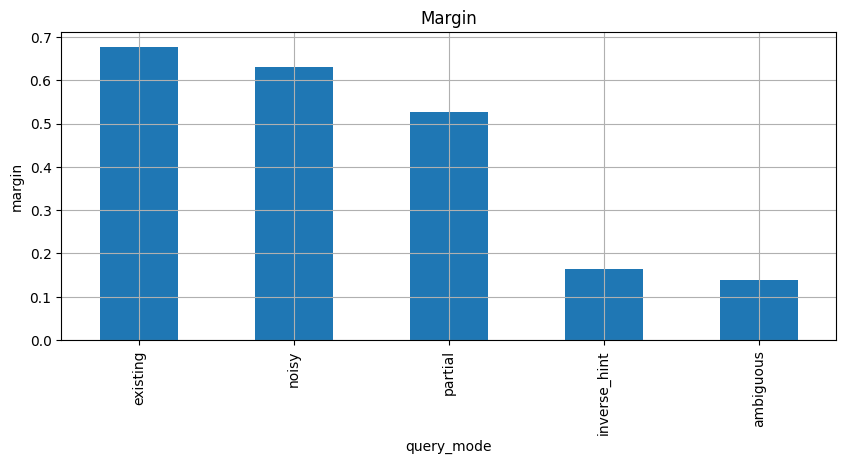

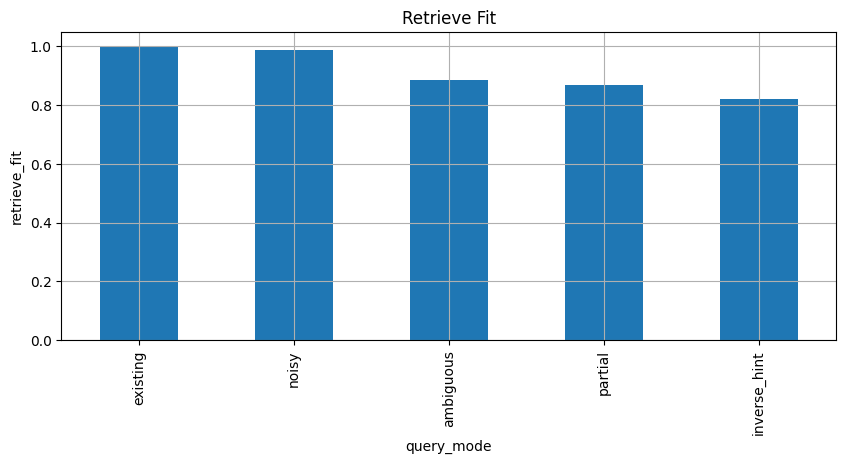

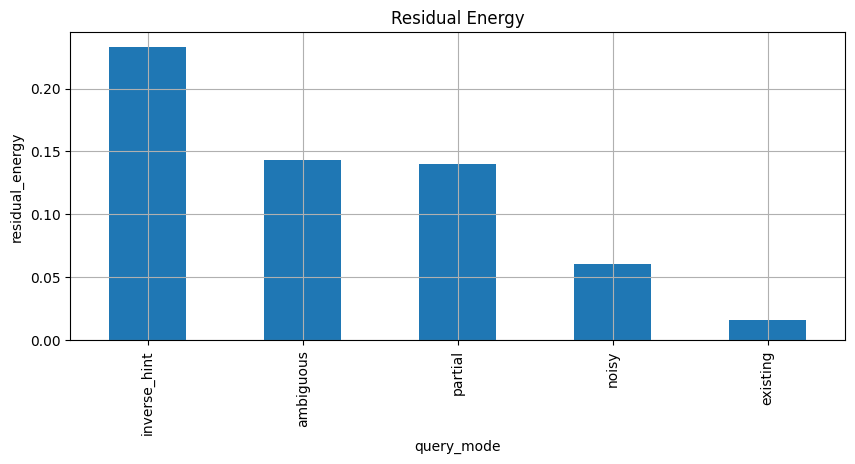

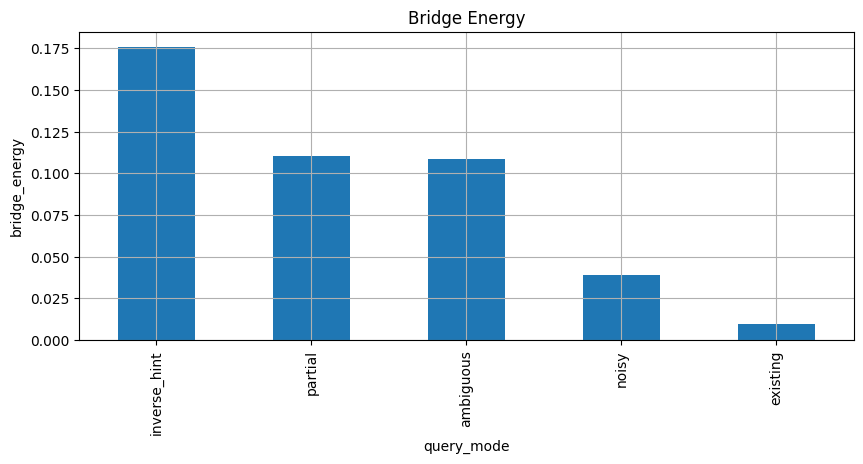

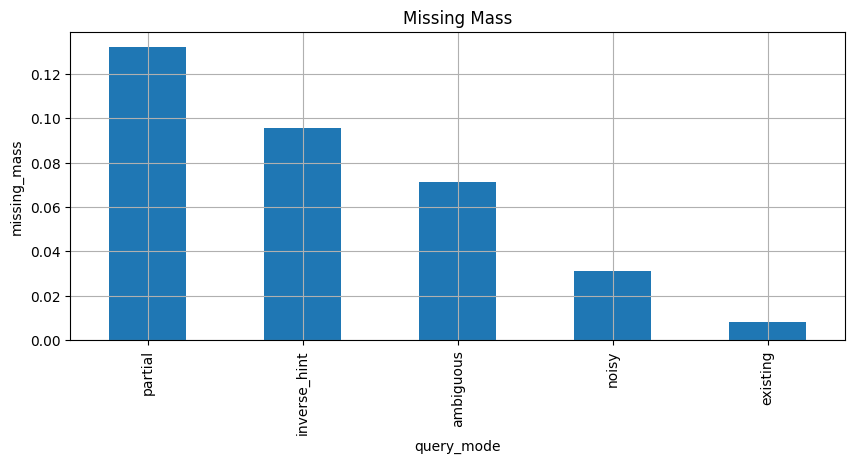

In [12]:

metrics = ["correct", "margin", "retrieve_fit", "residual_energy", "bridge_energy", "missing_mass"]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    grouped = triad_df.groupby("query_mode")[metric].mean().sort_values(ascending=False)
    grouped.plot(kind="bar")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("query_mode")
    plt.ylabel(metric)
    plt.show()



## Practical readout

This notebook gives the triad directly:

$$
\text{Shape} \to \text{Complement} \to \text{Declared Value}
$$

The same query shape can:
- retrieve something that already exists
- expose the missing complement of something partial

That is the controller law.

## Next move

If this direction is right, the next runtime should replace synthetic class molds with:
- real proposal traces
- real complement masks
- real fold fields

Then the same triadic controller becomes:

$$
Q \to (\text{retrieve mask},\ \text{missing mask},\ \text{declared value})
$$
